In [1]:
# Importing the necessary libraries
import torch
from torch import optim, utils, tensor, nn

import matplotlib.pyplot as plt
from getdist import plots, MCSamples

from Network import Generator, Discriminator
from Signal_Generator import *

from tqdm import tqdm

# Setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Defining the hyperparameters
datasize = 16000
num_sources = 1
noise_amplitude = 0
freq_range = (1e-4, 1e-1)
total_time = 1000

num_latent_variables = 20
learning_rate = 1e-5
weight_clip = 0.1

d_loss_threshold = -0.1
g_loss_threshold = -0.3
threshold_adjustment = 0.025
max_steps = 300

num_epochs = 2000

In [3]:
# Defining the distribution for amplitude and angular frequency
def amp_distribution(size):
    """
    Amplitude distribution using uniform distribution.
    """
    return np.random.uniform(4, 16, size=size)

def omega_distribution(size):
    """
    Angular frequency distribution using uniform distribution.
    """
    return np.random.uniform(2 * np.pi * 1e-4, 2 * np.pi * 1e-1, size=size)

In [4]:
# Defining the WGAN traning class
class WGAN(nn.Module):
    def __init__(self, num_latent_variables, lr, weight_clip):
        super(WGAN, self).__init__()
        self.num_latent_variables = num_latent_variables
        self.lr = lr
        self.weight_clip = weight_clip

        # Networks
        self.generator = Generator(in_channels=1, num_latent_variables=num_latent_variables, length=len(signal), num_parameters=len(params)).to(device)
        self.discriminator = Discriminator(input_channels=1, length=len(signal), num_parameters=len(params)).to(device)

        # Optimizers
        self.optimizer_g = optim.Adam(self.generator.parameters(), lr=self.lr)
        self.optimizer_d = optim.Adam(self.discriminator.parameters(), lr=self.lr)

    def wasserstein_loss(self, output_d, y):
        return torch.mean(output_d * y)
    
    def train_generator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_g.zero_grad()
        g_loss.backward()
        self.optimizer_g.step()

        return g_loss.item(), d_loss.item()
    
    def train_discriminator(self, signal_tensor, params_tensor, z):
        fake_params = self.generator(signal_tensor, z)
        fake_output = self.discriminator(signal_tensor, fake_params)
        real_output = self.discriminator(signal_tensor, params_tensor)
        g_loss = -torch.mean(fake_output)
        d_loss = -(torch.mean(real_output) - torch.mean(fake_output))

        self.optimizer_d.zero_grad()
        d_loss.backward()
        self.optimizer_d.step()

        # Weight clipping
        for p in self.discriminator.parameters():
            p.data.clamp_(-self.weight_clip, self.weight_clip)

        return g_loss.item(), d_loss.item()

In [22]:
generator = torch.load('generator_2000sig.pt')
Discriminator = torch.load('discriminator_2000sig.pt')

generator.eval()

Generator(
  (init_conv): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (init_relu): LeakyReLU(negative_slope=0.2)
  (res_block_no_norm): ResBlock(
    (conv1): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (leaky_relu): LeakyReLU(negative_slope=0.2)
  )
  (down1): Conditional_Down(
    (conv): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (relu): LeakyReLU(negative_slope=0.2)
    (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
    (res_block): Conditional_ResBlock(
      (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (conv3): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (leaky_relu): LeakyReLU(negative_slope=0.2)
      (process1): CIN(
        (inst_norm): InstanceNorm1d(

In [ ]:
generated_params_list = []

TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, freq_range=freq_range, total_time=total_time)
test_data = TS.generating_signal()
params = TS.printing_parameters()

input_signal = test_data['Signal'].values
input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

for i in range(10000):
    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    generated_params_list.append(generated_params)

print(params)
print(generated_params_list)

generated_params_df = pd.DataFrame(generated_params_list, columns=['Amplitude', 'Frequency', 'Phase'])

names = ["A","omega","theta"]
labels =  ["Amplitude","frequency","phase"]

generated_params_samples = MCSamples(samples=generated_params_df.values, names=names, labels=labels, settings={'ignore_rows': 1000})
generated_params_samples.updateSettings({'fine_bins_2D': 1048})

g = plots.get_subplot_plotter()

g.triangle_plot([generated_params_samples], filled=True)

axes = g.subplots

for i in range(len(names)):
    for j in range(i+1, len(names)):
        ax = axes[j, i]
        if ax is not None:
            ax.scatter(params[i], params[j], color='red', marker='o', s=50)

for i in range(len(names)):
    ax = axes[i, i]
    if ax is not None:
        ax.axvline(params[i], linestyle='--', color='red', lw=1)

handles = [plt.Line2D([0], [0], color='red', lw=2, linestyle='--', marker='o')] 
labels = ['Original Parameters']
g.fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.9, 0.9))

g.fig.tight_layout()
plt.suptitle(f'Triangle plots with fixed z for {num_epochs} epochs', fontsize=16, y=1.03)
plt.show()

In [ ]:
bias_mean = np.mean(generated_params_list - np.array(params), axis=0)
print(bias_mean)

In [ ]:
bias_var = np.var(generated_params_list - np.array(params), axis=0)
print(bias_var)

In [6]:
dataset = []

for i in range(16000):
    SG = Signal_Generator(num_sources=1, noise_amplitude=0)
    signals = SG.generating_signal()
    params = SG.printing_parameters()
    signal = signals['Signal'].values

    signal_tensor = torch.tensor(signal, dtype=torch.float).unsqueeze(0).to(device)
    params_tensor = torch.tensor(params, dtype=torch.float).to(device)

    dataset.append((signal_tensor, params_tensor))

train_loader = utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [5]:
wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

NameError: name 'signal' is not defined

In [12]:
wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

loss_list = []

for i in tqdm(range(1000)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        for i in range(5):
            z = torch.randn(1, num_latent_variables, 1).to(device)
            loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
            loss_list.append(loss)

        for i in range(1):
            z = torch.randn(1, num_latent_variables, 1).to(device)
            loss = wgan.train_generator(signal_tensor, params_tensor, z)
            loss_list.append(loss)

100%|██████████| 1000/1000 [4:04:14<00:00, 14.65s/it] 


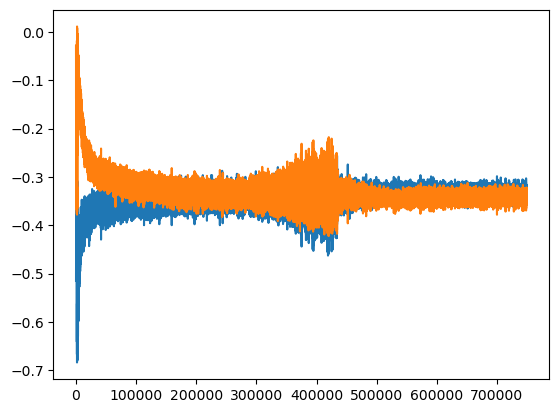

In [13]:
plt.plot(loss_list)

In [ ]:
learning_rates = [1e-4, 1e-5, 1e-6]

loss_dict = {}

# 遍历每个学习率
for lr in learning_rates:
    wgan = WGAN(num_latent_variables=num_latent_variables, lr=lr, weight_clip=0.1).to(device)
    loss_list = []
    
    # 开始训练
    for i in tqdm(range(10)):
        for _, (signal_tensor, params_tensor) in enumerate(train_loader):
            for i in range(5):
                z = torch.randn(1, num_latent_variables, 1).to(device)
                loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
                loss_list.append(loss)

            for i in range(1):
                z = torch.randn(1, num_latent_variables, 1).to(device)
                loss = wgan.train_generator(signal_tensor, params_tensor, z)
                loss_list.append(loss)
    
    loss_dict[lr] = loss_list

In [ ]:
lr = 1e-6

plt.figure(figsize=(10, 6))

plt.plot(loss_dict[lr], label=['Generator Loss', 'Discriminator Loss'])
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Loss Curve at a learning rate of {lr}')
plt.legend()

In [ ]:
weight_clips = [0.01, 0.1, 1]

wc_dict = {}

# 遍历每个学习率
for wc in weight_clips:
    wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=wc).to(device)
    loss_list = []
    
    # 开始训练
    for i in tqdm(range(10)):
        for _, (signal_tensor, params_tensor) in enumerate(train_loader):
            for i in range(5):
                z = torch.randn(1, num_latent_variables, 1).to(device)
                loss = wgan.train_discriminator(signal_tensor, params_tensor, z)
                loss_list.append(loss)

            for i in range(1):
                z = torch.randn(1, num_latent_variables, 1).to(device)
                loss = wgan.train_generator(signal_tensor, params_tensor, z)
                loss_list.append(loss)
    
    wc_dict[wc] = loss_list

In [ ]:
wc = 1

plt.figure(figsize=(10, 6))

plt.plot(wc_dict[wc], label=['Generator Loss', 'Discriminator Loss'])
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Loss Curve at a weight clip of {wc}')
plt.legend()

In [ ]:
wgan = WGAN(num_latent_variables=num_latent_variables, lr=learning_rate, weight_clip=0.1).to(device)

loss_list = []

for i in tqdm(range(100)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_generator(signal_tensor, params_tensor, z)
        loss_list.append(loss)

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(loss_list, label=['Generator Loss', 'Discriminator Loss'])
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Loss Curve for Critic with Generator Fixed')
plt.legend()

In [ ]:
""" for i in tqdm(range(50)):
    for _, (signal_tensor, params_tensor) in enumerate(train_loader):
        z = torch.randn(1, num_latent_variables, 1).to(device)
        loss = wgan.train_generator(signal_tensor, params_tensor, z)
        loss_list.append(loss) """

In [16]:
generator = wgan.generator

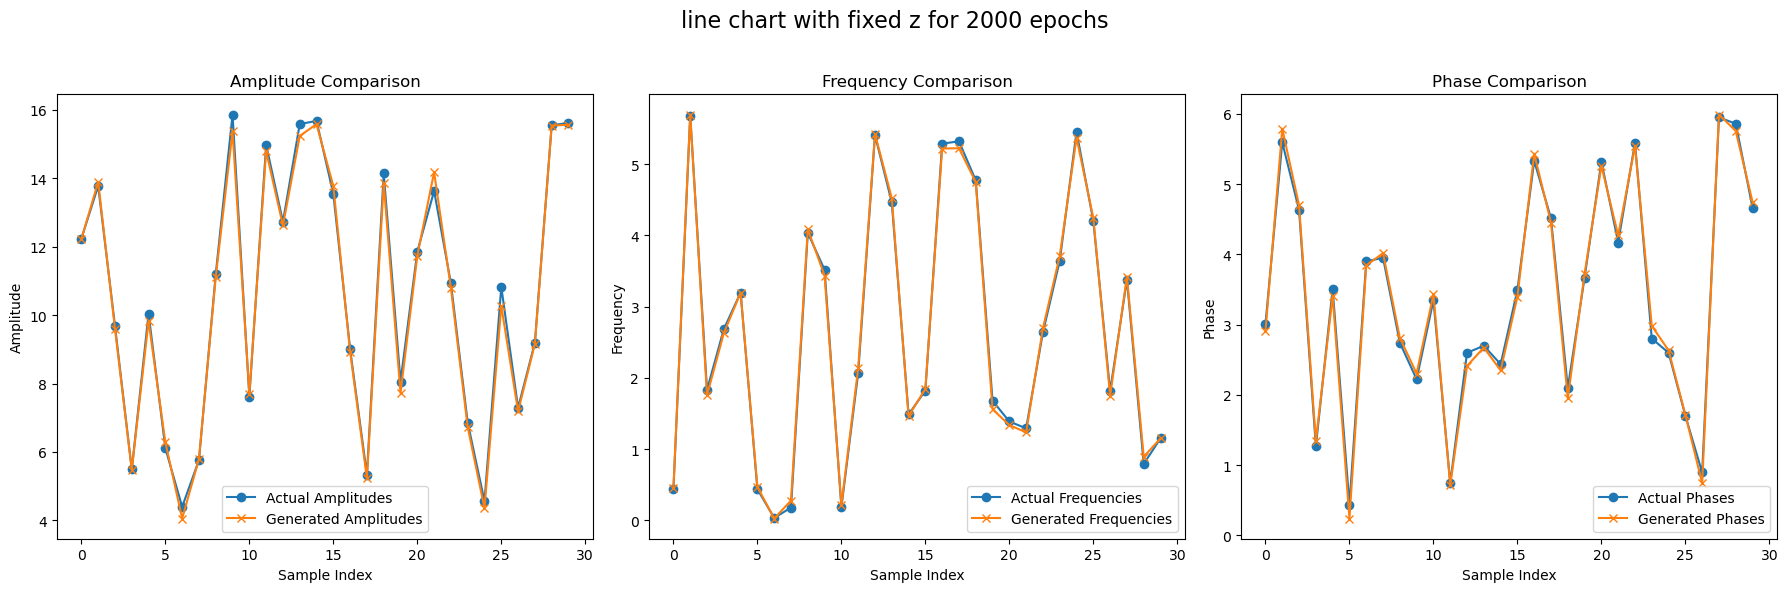

In [23]:
params_list = []
generated_params_list = []

test_times = 30
for i in range(test_times):
    TS = Signal_Generator(num_sources=num_sources, noise_amplitude=noise_amplitude, amp_distribution_func=amp_distribution
                          , omega_distribution_func=omega_distribution, freq_range=freq_range, total_time=total_time)
    test_data = TS.generating_signal()
    params = TS.printing_parameters()

    input_signal = test_data['Signal'].values
    input_signal_tensor = torch.tensor(input_signal, dtype=torch.float).unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        z = torch.randn(1, num_latent_variables, 1).to(device)
        generated_params = generator(input_signal_tensor, z).squeeze().cpu().numpy()

    params_list.append(params)
    generated_params_list.append(generated_params)

    #print(params)
    #print(generated_params)

actual_amplitudes = [params[0] for params in params_list]
actual_frequencies = [params[1] for params in params_list]
actual_phases = [params[2] for params in params_list]

generated_amplitudes = [gen_params[0] for gen_params in generated_params_list]
generated_frequencies = [gen_params[1] for gen_params in generated_params_list]
generated_phases = [gen_params[2] for gen_params in generated_params_list]

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(range(test_times), actual_amplitudes, 'o-', label='Actual Amplitudes')
plt.plot(range(test_times), generated_amplitudes, 'x-', label='Generated Amplitudes')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Amplitude Comparison')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(range(test_times), actual_frequencies, 'o-', label='Actual Frequencies')
plt.plot(range(test_times), generated_frequencies, 'x-', label='Generated Frequencies')
plt.xlabel('Sample Index')
plt.ylabel('Frequency')
plt.title('Frequency Comparison')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(range(test_times), actual_phases, 'o-', label='Actual Phases')
plt.plot(range(test_times), generated_phases, 'x-', label='Generated Phases')
plt.xlabel('Sample Index')
plt.ylabel('Phase')
plt.title('Phase Comparison')
plt.legend()

plt.suptitle(f'line chart with fixed z for {num_epochs} epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [24]:
bias = [generated - params for generated, params in zip(generated_params_list, params_list)]
print(bias)

[array([-0.01838671,  0.01811722, -0.09819814]), array([0.12263856, 0.01464138, 0.19256271]), array([-0.08156078, -0.07614859,  0.06781903]), array([-0.01276336, -0.05613979,  0.07484594]), array([-0.21736399, -0.00070252, -0.10307667]), array([ 0.17129733,  0.03147043, -0.19927212]), array([-0.34304732, -0.00794599, -0.05735123]), array([0.03285057, 0.09874161, 0.06554732]), array([-0.08282869,  0.04899226,  0.06854461]), array([-0.49377667, -0.08217668,  0.08250933]), array([0.08816208, 0.0304344 , 0.0846763 ]), array([-0.18537274,  0.06875194, -0.0324091 ]), array([-0.11113838,  0.01748038, -0.18705295]), array([-0.34780524,  0.05894042, -0.02606487]), array([-0.09281684, -0.02237758, -0.08798327]), array([ 0.22506499,  0.02303456, -0.09501337]), array([-0.07713315, -0.06919772,  0.10216913]), array([-0.10559903, -0.09680341, -0.06296464]), array([-0.28902375, -0.02434275, -0.14624495]), array([-0.33552871, -0.11969831,  0.05296585]), array([-0.11709553, -0.05002977, -0.06028474]), 

In [25]:
bias_mean = np.mean(bias, axis=0)
print(bias_mean)

[-0.09857884 -0.00340706 -0.00726968]


In [26]:
bias_var = np.var(bias, axis=0)
print(bias_var)

[0.04480317 0.00357927 0.01056768]
